# Clasificación de Daños en la Malla Vial de la Provincia del Sumapaz mediante Redes Neuronales Convolucionales

**Brayant Vásquez Gómez, Erika Lorena Teusa Reina**

Gestor del Conocimiento: German Ortiz Diaz

Universidad de Cundinamarca
Facultad de Ingeniería
Programa de Ingeniería de Sistemas y Computación
Inteligencia Artificial, 803 M

Septiembre de 2026

---

### Actividad R1-A2-S4 — "Redes que aprenden del mundo"

Este notebook da continuidad al problema identificado en la actividad R1-A1-S1
(deterioro de la malla vial terciaria en la Provincia del Sumapaz). En esa fase se
validó de forma exploratoria la viabilidad del enfoque con un prototipo en
Teachable Machine. En esta fase se entrena una red neuronal convolucional (CNN)
real sobre un dataset de fotografías reales, siguiendo tres etapas:

1. **Semana 4** — Carga y limpieza de datos.
2. **Semana 5** — Entrenamiento del modelo en Google Colab.
3. **Semana 6** — Evaluación, optimización y reflexión ética.

**Simplificación del esquema de clases:** el documento original proponía 4 clases
(buen estado, grietas, huecos pequeños, huecos grandes). Para esta fase se
simplifica a **3 clases** (buen estado / grietas / huecos), ya que ningún dataset
público trae la severidad del hueco pre-etiquetada y separarla manualmente por
tamaño de bounding box añadía una complejidad desproporcionada para el alcance de
esta actividad. Sigue siendo un problema de clasificación de imágenes válido y
con respaldo empírico (Rique-Sabogal et al., 2025).


## 1. Preparación del entorno

In [ ]:
!pip install -q kagglehub imagehash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.8 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import random
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU disponible: []


## 2. Carga de datos (Semana 4)

Se descargan dos datasets públicos de Kaggle mediante `kagglehub`. Al ejecutar la
siguiente celda, Colab pedirá iniciar sesión con tu cuenta de Kaggle (no hace
falta subir ningún archivo `kaggle.json` manualmente).

- **Dataset 1**: `virenbr11/pothole-and-plain-rode-images` — imágenes ya
  organizadas en "plain" (vía en buen estado) y "pothole" (vía con hueco).
- **Dataset 2**: `lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes`
  — 2,009 imágenes reales con anotaciones de 3 clases: Pothole (0), Crack (1) y
  Manhole (2). De aquí se extraen las clases **grietas** y un refuerzo de
  **huecos**.


In [ ]:
path_ds1 = kagglehub.dataset_download("virenbr11/pothole-and-plain-rode-images")
path_ds2 = kagglehub.dataset_download("lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes")

print("Dataset 1 (plain/pothole):", path_ds1)
print("Dataset 2 (road damage):", path_ds2)


100%|██████████| 241M/241M [00:06<00:00, 36.3MB/s]

Extracting files...


100%|██████████| 185M/185M [00:05<00:00, 34.2MB/s]

Extracting files...


Dataset 1 (plain/pothole): /root/.cache/kagglehub/datasets/virenbr11/pothole-and-plain-rode-images/versions/1
Dataset 2 (road damage): /root/.cache/kagglehub/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes/versions/4


### 2.1 Diagnóstico de estructura

**Importante:** revisa la salida de esta celda antes de continuar. La estructura
interna exacta de las carpetas descargadas puede variar; si los conteos salen en
0 en los pasos siguientes, es señal de que hay que ajustar las palabras clave de
búsqueda (`"plain"`, `"pothole"`, `"crack"`) según lo que se imprima aquí.


In [ ]:
def inspeccionar_arbol(root, max_items=25):
    print(f"--- Estructura de: {root} ---")
    contador = 0
    for dirpath, dirnames, filenames in os.walk(root):
        nivel = dirpath.replace(str(root), "").count(os.sep)
        indent = "  " * nivel
        print(f"{indent}{os.path.basename(dirpath)}/  ({len(filenames)} archivos)")
        contador += 1
        if contador >= max_items:
            print(f"{indent}... (truncado)")
            break

inspeccionar_arbol(path_ds1)
print()
inspeccionar_arbol(path_ds2)


--- Estructura de: /root/.cache/kagglehub/datasets/virenbr11/pothole-and-plain-rode-images/versions/1 ---
1/  (0 archivos)
  My Dataset/  (0 archivos)
    test/  (0 archivos)
      Plain/  (8 archivos)
      Pothole/  (8 archivos)
    train/  (0 archivos)
      Plain/  (367 archivos)
      Pothole/  (357 archivos)

--- Estructura de: /root/.cache/kagglehub/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes/versions/4 ---
4/  (0 archivos)
  data/  (4 archivos)
    labels/  (2009 archivos)
    labels-YOLO/  (2009 archivos)
    images/  (2009 archivos)


## 3. Organización en las 3 clases objetivo

**Mapeo de fuentes:**

| Clase | Origen |
|---|---|
| `buen_estado` | carpeta "Plain" del Dataset 1 |
| `huecos` | carpeta "Pothole" del Dataset 1 + imágenes del Dataset 2 donde la **única** clase anotada es Pothole (0) |
| `grietas` | imágenes del Dataset 2 donde la **única** clase anotada es Crack (1) |

Las imágenes del Dataset 2 que combinan varias clases a la vez (ej. pothole +
crack en la misma foto) o que solo contienen manhole se **descartan** — es una
decisión de limpieza: para clasificación de una sola etiqueta por imagen, una
foto con daños mixtos introduce ruido en el entrenamiento.


In [ ]:
BASE_DIR = Path("/content/dataset_vial")
RAW_DIR = BASE_DIR / "raw"
CLASSES = ["buen_estado", "grietas", "huecos"]

for c in CLASSES:
    (RAW_DIR / c).mkdir(parents=True, exist_ok=True)

def buscar_carpetas(root, palabra_clave):
    """Busca subcarpetas cuyo nombre contenga la palabra clave (sin importar mayúsculas)."""
    encontradas = []
    for dirpath, dirnames, _ in os.walk(root):
        if palabra_clave.lower() in os.path.basename(dirpath).lower():
            encontradas.append(dirpath)
    return encontradas

def copiar_imagenes(carpeta_origen, carpeta_destino, prefijo):
    extensiones = (".jpg", ".jpeg", ".png")
    n = 0
    for archivo in os.listdir(carpeta_origen):
        if archivo.lower().endswith(extensiones):
            origen = os.path.join(carpeta_origen, archivo)
            destino = os.path.join(carpeta_destino, f"{prefijo}_{n:05d}{Path(archivo).suffix.lower()}")
            shutil.copyfile(origen, destino)
            n += 1
    return n


In [ ]:
# --- Dataset 1: plain -> buen_estado, pothole -> huecos ---
carpetas_plain = buscar_carpetas(path_ds1, "plain")
carpetas_pothole_ds1 = buscar_carpetas(path_ds1, "pothole")

total_buen_estado = 0
for carpeta in carpetas_plain:
    total_buen_estado += copiar_imagenes(carpeta, RAW_DIR / "buen_estado", "ds1plain")

total_huecos_ds1 = 0
for carpeta in carpetas_pothole_ds1:
    total_huecos_ds1 += copiar_imagenes(carpeta, RAW_DIR / "huecos", "ds1pothole")

print(f"Dataset 1 -> buen_estado: {total_buen_estado} imágenes")
print(f"Dataset 1 -> huecos: {total_huecos_ds1} imágenes")


Dataset 1 -> buen_estado: 374 imágenes
Dataset 1 -> huecos: 365 imágenes


In [ ]:
# --- Dataset 2: parsear etiquetas para separar crack vs pothole ---
# Mapeo documentado en la ficha del dataset: 0 = Pothole, 1 = Crack, 2 = Manhole
CLASS_MAP_DS2 = {0: "huecos", 1: "grietas", 2: None}  # None = se descarta (manhole)

carpetas_labels = buscar_carpetas(path_ds2, "label")
carpetas_images = buscar_carpetas(path_ds2, "image")

assert carpetas_labels, "No se encontró carpeta de labels en el Dataset 2 — revisa el diagnóstico de estructura arriba."
assert carpetas_images, "No se encontró carpeta de images en el Dataset 2 — revisa el diagnóstico de estructura arriba."

dir_labels = carpetas_labels[0]
dir_images = carpetas_images[0]
print("Usando labels de:", dir_labels)
print("Usando imágenes de:", dir_images)

# Muestra el contenido de un archivo de etiqueta para verificar el formato
ejemplo_label = next((f for f in os.listdir(dir_labels) if f.endswith(".txt")), None)
if ejemplo_label:
    with open(os.path.join(dir_labels, ejemplo_label)) as f:
        print(f"\nEjemplo de etiqueta ({ejemplo_label}):")
        print(f.read()[:300])


Usando labels de: /root/.cache/kagglehub/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes/versions/4/data/labels
Usando imágenes de: /root/.cache/kagglehub/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes/versions/4/data/images

Ejemplo de etiqueta (vlcsnap-00103.txt):
1 0.004687 0.658333 0.309375 0.658333 0.309375 0.819444 0.004687 0.819444
1 0.337500 0.622222 0.435937 0.622222 0.435937 0.711111 0.337500 0.711111
1 0.331250 0.730556 0.479687 0.730556 0.479687 0.805556 0.331250 0.805556
2 0.473438 0.697222 0.556250 0.697222 0.556250 0.750000 0.473438 0.750000



In [ ]:
def clases_presentes_en_label(ruta_txt):
    """Lee un archivo de etiquetas (formato YOLO/OBB) y devuelve el conjunto de
    class_id presentes (siempre es el primer valor de cada línea)."""
    clases = set()
    with open(ruta_txt) as f:
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            class_id = int(float(linea.split()[0]))
            clases.add(class_id)
    return clases

conteo_por_clase = {"grietas": 0, "huecos": 0, "descartadas_mixtas_o_manhole": 0}

for archivo_label in os.listdir(dir_labels):
    if not archivo_label.endswith(".txt"):
        continue
    ruta_txt = os.path.join(dir_labels, archivo_label)
    clases_ids = clases_presentes_en_label(ruta_txt)

    # solo nos sirven imágenes con una única clase de daño anotada
    if len(clases_ids) != 1:
        conteo_por_clase["descartadas_mixtas_o_manhole"] += 1
        continue

    clase_id = next(iter(clases_ids))
    clase_destino = CLASS_MAP_DS2.get(clase_id)
    if clase_destino is None:
        conteo_por_clase["descartadas_mixtas_o_manhole"] += 1
        continue

    stem = Path(archivo_label).stem
    ruta_imagen = None
    for ext in (".jpg", ".jpeg", ".png"):
        candidato = os.path.join(dir_images, stem + ext)
        if os.path.exists(candidato):
            ruta_imagen = candidato
            break

    if ruta_imagen is None:
        continue

    n = conteo_por_clase[clase_destino]
    destino = RAW_DIR / clase_destino / f"ds2_{n:05d}{Path(ruta_imagen).suffix.lower()}"
    shutil.copyfile(ruta_imagen, destino)
    conteo_por_clase[clase_destino] += 1

print("Resultado del filtrado del Dataset 2:")
for k, v in conteo_por_clase.items():
    print(f"  {k}: {v}")


Resultado del filtrado del Dataset 2:
  grietas: 691
  huecos: 162
  descartadas_mixtas_o_manhole: 1156


In [ ]:
print("Conteo bruto (raw) por clase antes de limpiar:")
for c in CLASSES:
    n = len(list((RAW_DIR / c).glob("*")))
    print(f"  {c}: {n} imágenes")


Conteo bruto (raw) por clase antes de limpiar:
  buen_estado: 366 imágenes
  grietas: 691 imágenes
  huecos: 520 imágenes


## 4. Limpieza de datos (Semana 4)

Se aplican los siguientes criterios de limpieza sobre las imágenes copiadas:

1. **Integridad**: se descartan archivos corruptos o ilegibles.
2. **Formato**: todas las imágenes se convierten a RGB y se guardan como JPG.
3. **Resolución mínima**: se descartan imágenes menores a 64×64 px (muy
   pixeladas, no aportan información útil a la CNN).
4. **Duplicados**: se calcula un hash perceptual por imagen (`imagehash`) y se
   eliminan duplicados o casi-duplicados dentro de la misma clase.

Se documenta cuántas imágenes se pierden en cada filtro, como evidencia del
proceso de limpieza.


In [ ]:
RESOLUCION_MINIMA = (64, 64)
CLEAN_DIR = BASE_DIR / "clean"

reporte_limpieza = []

for clase in CLASSES:
    (CLEAN_DIR / clase).mkdir(parents=True, exist_ok=True)

    archivos = list((RAW_DIR / clase).glob("*"))
    total_inicial = len(archivos)
    corruptas = 0
    baja_resolucion = 0
    duplicadas = 0
    hashes_vistos = set()
    n_final = 0

    for archivo in archivos:
        try:
            img = Image.open(archivo)
            img.verify()
            img = Image.open(archivo)  # se reabre porque verify() invalida el objeto
        except Exception:
            corruptas += 1
            continue

        if img.size[0] < RESOLUCION_MINIMA[0] or img.size[1] < RESOLUCION_MINIMA[1]:
            baja_resolucion += 1
            continue

        h = str(imagehash.average_hash(img))
        if h in hashes_vistos:
            duplicadas += 1
            continue
        hashes_vistos.add(h)

        img_rgb = img.convert("RGB")
        destino = CLEAN_DIR / clase / f"{clase}_{n_final:05d}.jpg"
        img_rgb.save(destino, "JPEG", quality=90)
        n_final += 1

    reporte_limpieza.append({
        "clase": clase,
        "imagenes_iniciales": total_inicial,
        "corruptas_removidas": corruptas,
        "baja_resolucion_removidas": baja_resolucion,
        "duplicadas_removidas": duplicadas,
        "imagenes_finales": n_final,
    })

df_reporte = pd.DataFrame(reporte_limpieza)
df_reporte


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,clase,imagenes_iniciales,corruptas_removidas,baja_resolucion_removidas,duplicadas_removidas,imagenes_finales
0,buen_estado,366,0,0,7,359
1,grietas,691,0,0,21,670
2,huecos,520,0,0,8,512


## 5. Balanceo de clases

Se ajustan las clases al tamaño de la clase minoritaria (undersampling
aleatorio), para que el modelo no aprenda a favorecer la clase con más
ejemplos.


In [ ]:
BALANCED_DIR = BASE_DIR / "balanced"

conteos = {c: len(list((CLEAN_DIR / c).glob("*"))) for c in CLASSES}
n_min = min(conteos.values())
print("Conteo tras limpieza:", conteos)
print("Tamaño objetivo por clase (undersampling):", n_min)

for clase in CLASSES:
    (BALANCED_DIR / clase).mkdir(parents=True, exist_ok=True)
    archivos = list((CLEAN_DIR / clase).glob("*"))
    seleccion = random.sample(archivos, n_min)
    for archivo in seleccion:
        shutil.copyfile(archivo, BALANCED_DIR / clase / archivo.name)

print("\nConteo final balanceado:")
for c in CLASSES:
    print(f"  {c}: {len(list((BALANCED_DIR / c).glob('*')))} imágenes")


Conteo tras limpieza: {'buen_estado': 359, 'grietas': 670, 'huecos': 512}
Tamaño objetivo por clase (undersampling): 359

Conteo final balanceado:
  buen_estado: 359 imágenes
  grietas: 359 imágenes
  huecos: 359 imágenes


## 6. Visualización del dataset

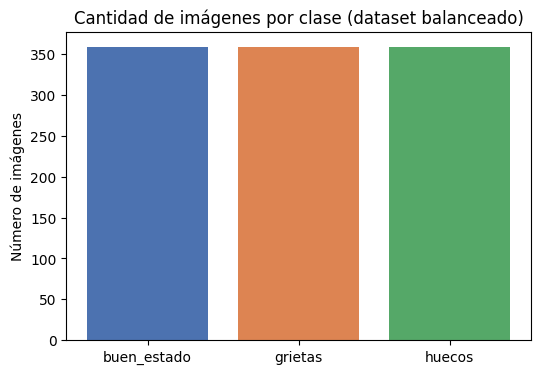

In [ ]:
conteos_finales = {c: len(list((BALANCED_DIR / c).glob("*"))) for c in CLASSES}

plt.figure(figsize=(6, 4))
plt.bar(conteos_finales.keys(), conteos_finales.values(), color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Cantidad de imágenes por clase (dataset balanceado)")
plt.ylabel("Número de imágenes")
plt.show()


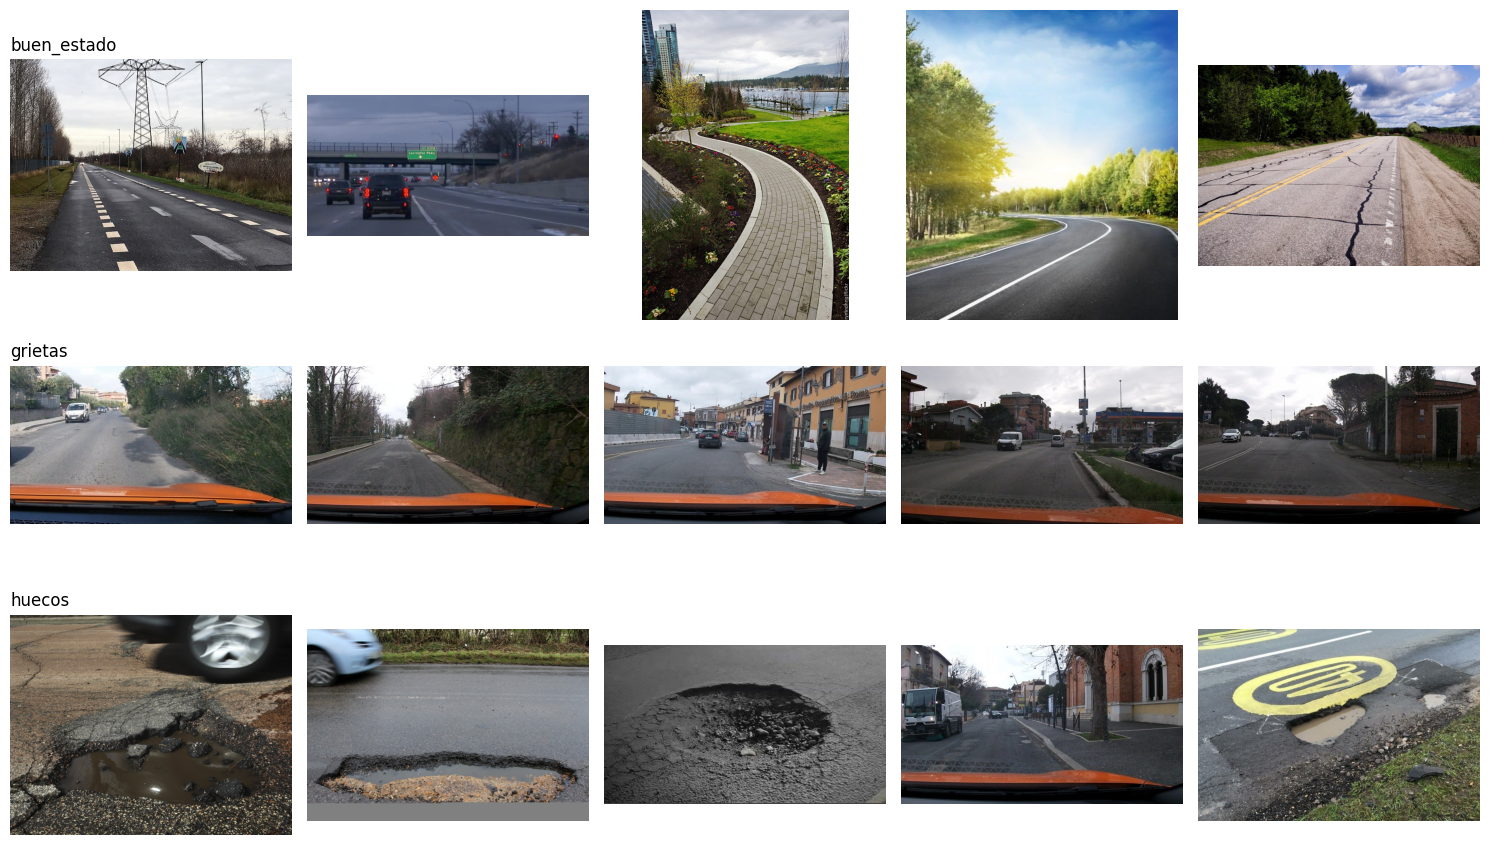

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, clase in enumerate(CLASSES):
    archivos = list((BALANCED_DIR / clase).glob("*"))[:5]
    for j, archivo in enumerate(archivos):
        img = Image.open(archivo)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
    axes[i, 0].set_title(clase, fontsize=12, loc="left")
plt.tight_layout()
plt.show()


## 7. División train / validación / test

Se usa una división estratificada 70% / 15% / 15% por clase.


In [ ]:
SPLIT_DIR = BASE_DIR / "split"
proporciones = {"train": 0.70, "val": 0.15, "test": 0.15}

for subset in proporciones:
    for c in CLASSES:
        (SPLIT_DIR / subset / c).mkdir(parents=True, exist_ok=True)

for clase in CLASSES:
    archivos = list((BALANCED_DIR / clase).glob("*"))
    train_files, temp_files = train_test_split(archivos, test_size=0.30, random_state=SEED)
    val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=SEED)

    for subset, files in zip(["train", "val", "test"], [train_files, val_files, test_files]):
        for archivo in files:
            shutil.copyfile(archivo, SPLIT_DIR / subset / clase / archivo.name)

for subset in proporciones:
    conteo = {c: len(list((SPLIT_DIR / subset / c).glob("*"))) for c in CLASSES}
    print(f"{subset}: {conteo}")


train: {'buen_estado': 251, 'grietas': 251, 'huecos': 251}
val: {'buen_estado': 54, 'grietas': 54, 'huecos': 54}
test: {'buen_estado': 54, 'grietas': 54, 'huecos': 54}


## 8. Preprocesamiento y aumento de datos (Semana 5)

Se cargan los conjuntos con `image_dataset_from_directory` y se aplica aumento
de datos (flip horizontal, rotación y zoom leves) solo al conjunto de
entrenamiento, para hacer al modelo más robusto a variaciones de ángulo e
iluminación típicas de fotos tomadas con celular.


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train", labels="inferred", label_mode="int",
    class_names=CLASSES, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "val", labels="inferred", label_mode="int",
    class_names=CLASSES, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED,
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test", labels="inferred", label_mode="int",
    class_names=CLASSES, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)

augmentacion = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (augmentacion(x, training=True), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 753 files belonging to 3 classes.
Found 162 files belonging to 3 classes.
Found 162 files belonging to 3 classes.


## 9. Arquitectura del modelo — Transfer Learning con MobileNetV2

Se usa MobileNetV2 preentrenada en ImageNet como extractor de características,
congelada inicialmente, con una cabeza de clasificación propia para las 3
clases. Se eligió transfer learning en vez de una CNN entrenada desde cero
(como en el clasificador de huevos) porque el dataset combinado, tras limpieza
y balanceo, es relativamente pequeño — transfer learning generaliza mejor con
pocos datos.


In [ ]:
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = layers.Lambda(preprocess_input)(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASSES), activation="softmax")(x)

modelo = tf.keras.Model(inputs, outputs)

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

modelo.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 9.1 Entrenamiento — fase 1 (base congelada)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
]

historial_1 = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
)


Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.7224 - loss: 0.6764 - val_accuracy: 0.8580 - val_loss: 0.3498
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8433 - loss: 0.4090 - val_accuracy: 0.8827 - val_loss: 0.2857
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8685 - loss: 0.3503 - val_accuracy: 0.9012 - val_loss: 0.2640
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8712 - loss: 0.3122 - val_accuracy: 0.8827 - val_loss: 0.2438
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8805 - loss: 0.2989 - val_accuracy: 0.8889 - val_loss: 0.2617
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8845 - loss: 0.2685 - val_accuracy: 0.8889 - val_loss: 0.2497
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9017 - loss: 0.2540 - val_accuracy: 0.8889 - val_loss: 0.2442
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9230 - loss: 0.2067 - val_accuracy: 0.9136 - val_loss:

### 9.2 Entrenamiento — fase 2 (fine-tuning)

Se descongelan las últimas capas de MobileNetV2 y se continúa el entrenamiento
con una tasa de aprendizaje mucho más baja, para ajustar finamente las
características al dominio específico de fotos de vías.


In [ ]:
base_model.trainable = True
for capa in base_model.layers[:-30]:
    capa.trainable = False

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

historial_2 = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.7742 - loss: 0.5772 - val_accuracy: 0.9198 - val_loss: 0.1819
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.8406 - loss: 0.3987 - val_accuracy: 0.9198 - val_loss: 0.1818
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.8778 - loss: 0.3439 - val_accuracy: 0.9259 - val_loss: 0.1782
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.8884 - loss: 0.2638 - val_accuracy: 0.9321 - val_loss: 0.1759
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9004 - loss: 0.2457 - val_accuracy: 0.9321 - val_loss: 0.1730
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9110 - loss: 0.2377 - val_accuracy: 0.9321 - val_loss: 0.1700
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.9070 - loss: 0.2315 - val_accuracy: 0.9321 - val_loss: 0.1692
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9190 - loss: 0.2095 - val_accuracy: 0.9321 - val_loss:

## 10. Evaluación del modelo (Semana 6)

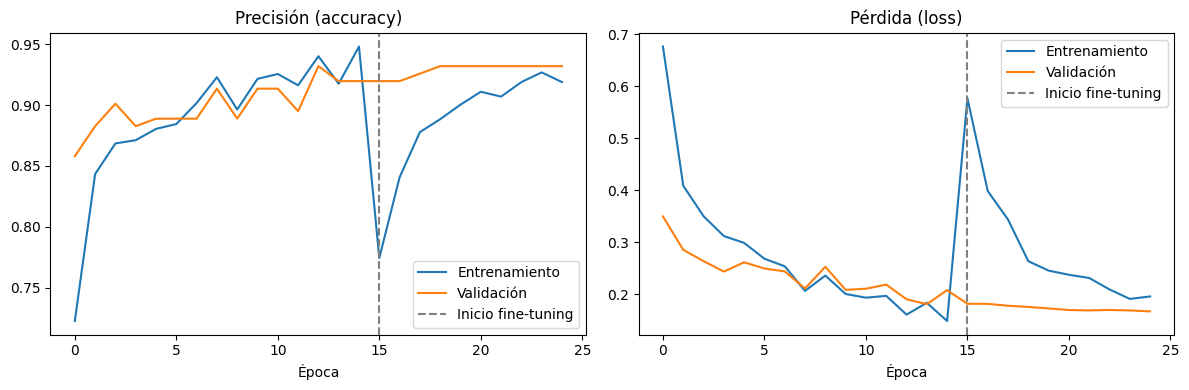

In [ ]:
def combinar_historiales(h1, h2, clave):
    return h1.history[clave] + h2.history[clave]

acc = combinar_historiales(historial_1, historial_2, "accuracy")
val_acc = combinar_historiales(historial_1, historial_2, "val_accuracy")
loss = combinar_historiales(historial_1, historial_2, "loss")
val_loss = combinar_historiales(historial_1, historial_2, "val_loss")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(acc, label="Entrenamiento")
axes[0].plot(val_acc, label="Validación")
axes[0].axvline(len(historial_1.history["accuracy"]), color="gray", linestyle="--", label="Inicio fine-tuning")
axes[0].set_title("Precisión (accuracy)")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(loss, label="Entrenamiento")
axes[1].plot(val_loss, label="Validación")
axes[1].axvline(len(historial_1.history["loss"]), color="gray", linestyle="--", label="Inicio fine-tuning")
axes[1].set_title("Pérdida (loss)")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_acc = modelo.evaluate(test_ds)
print(f"Precisión en test: {test_acc:.4f}")
print(f"Pérdida en test: {test_loss:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8704 - loss: 0.3459
Precisión en test: 0.8704
Pérdida en test: 0.3459


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
              precision    recall  f1-score   support

 buen_estado       0.93      0.96      0.95        54
     grietas       0.85      0.85      0.85        54
      huecos       0.83      0.80      0.81        54

    accuracy                           0.87       162
   macro avg       0.87      0.87      0.87       162
weighted avg       0.87      0.87      0.87       162



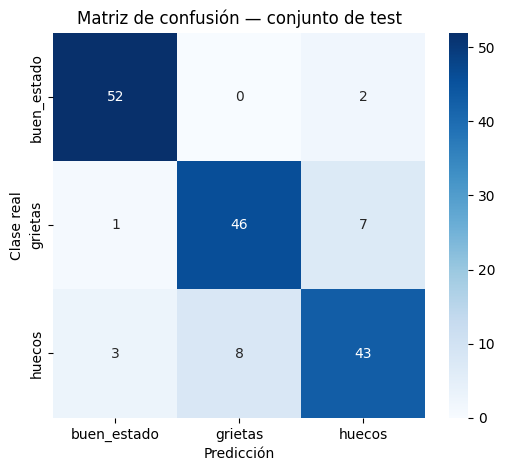

In [ ]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = modelo.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=CLASSES))

matriz = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión — conjunto de test")
plt.show()


In [ ]:
modelo.save("/content/modelo_vial_sumapaz.keras")
print("Modelo guardado en /content/modelo_vial_sumapaz.keras")
# Para conservarlo más allá de esta sesión de Colab, monta Google Drive y copia el
# archivo, ej:
# from google.colab import drive
# drive.mount('/content/drive')
# shutil.copyfile("/content/modelo_vial_sumapaz.keras", "/content/drive/MyDrive/modelo_vial_sumapaz.keras")


Modelo guardado en /content/modelo_vial_sumapaz.keras


Saving Captura de pantalla 2026-09-13 223426.png to Captura de pantalla 2026-09-13 223426 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


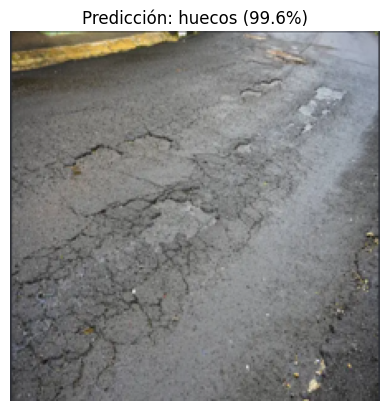

  buen_estado: 0.0%
  grietas: 0.4%
  huecos: 99.6%


In [ ]:
from google.colab import files
import numpy as np

uploaded = files.upload()  # se abre un selector para subir una foto

for nombre in uploaded.keys():
    img = Image.open(nombre).convert("RGB").resize(IMG_SIZE)
    entrada = np.expand_dims(np.array(img), axis=0)
    pred = modelo.predict(entrada)
    clase = CLASSES[np.argmax(pred)]
    confianza = np.max(pred) * 100

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicción: {clase} ({confianza:.1f}%)")
    plt.show()

    for c, p in zip(CLASSES, pred[0]):
        print(f"  {c}: {p*100:.1f}%")

## 11. Conclusiones preliminares

*(sección a completar una vez se tengan los resultados finales de entrenamiento
en Colab; esta versión deja la estructura y las preguntas guía)*

- ¿La precisión obtenida en test es consistente con la reportada por
  Rique-Sabogal et al. (2025) para tareas similares de clasificación de daños
  viales?
- ¿Qué clase presenta más confusión en la matriz de confusión, y por qué
  podría estar pasando (ej. huecos pequeños que visualmente se parecen a
  grietas)?
- **Reflexión ética pendiente (Semana 6):** sesgos del dataset (imágenes de
  Roma/Sacrofano e India, no de Colombia — el modelo puede no generalizar bien
  a la textura de pavimento local), riesgo de falsos negativos que dejen vías
  peligrosas sin reportar, y manejo de la ubicación GPS asociada a cada
  reporte ciudadano.
- **Cuestionario de 10 preguntas** de la actividad: pendiente de resolver en
  Moodle.

## Referencias

Rique-Sabogal, A. P., Guatame-Medina, M. A., Moreno-Manrique, C. F.,
Jiménez-López, F. R., & Jiménez-López, A. F. (2025). Análisis estructural de
baches viales mediante redes neuronales profundas. *TecnoLógicas, 28*(63),
e3266. https://doi.org/10.22430/22565337.3266

Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. C. (2018).
MobileNetV2: Inverted residuals and linear bottlenecks. *Proceedings of the
IEEE Conference on Computer Vision and Pattern Recognition*, 4510-4520.

Arcioni, L. (2026). *Road Damage Dataset: Potholes, Cracks and Manholes*
[Conjunto de datos]. Kaggle.
https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes

Basily, V. (2019). *Pothole and Plain Road Images* [Conjunto de datos].
Kaggle. https://www.kaggle.com/datasets/virenbr11/pothole-and-plain-rode-images
